In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
from multiprocessing import Pool
from catboost import CatBoostRegressor
from hyperopt import hp, tpe, Trials, STATUS_OK, fmin
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")
from flaml import AutoML
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import shap
from tqdm import tqdm
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, 
    AdaBoostRegressor, BaggingRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Lasso, LassoLars, LinearRegression, Ridge,
    SGDRegressor, PassiveAggressiveRegressor, ElasticNet, HuberRegressor,
    BayesianRidge, OrthogonalMatchingPursuit
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import NuSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
train=pd.read_csv('/home/ychen3338/project_2/data/m_train.csv')
test=pd.read_csv('/home/ychen3338/project_2/data/m_test.csv')

In [3]:
class morgan_fp:
    def __init__(self, radius, length):
        self.radius = radius
        self.length = length
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, self.length)
        npfp = np.array(list(fp.ToBitString())).astype('float32')
        return npfp

In [4]:
def conv_data(data, fp):
    data['c-fp'] = data['Cation'].apply(fp)
    x_c=np.array(list(data['c-fp']))
    data['a-fp'] = data['Anion'].apply(fp)
    x_a=np.array(list(data['a-fp']))
    xx = np.concatenate([x_c, x_a], axis =1)
    y = data['Tm'].values
    return xx, y

In [5]:
# result = pd.read_csv('/home/ychen3338/project_2/code/melting/melting_MF.csv')
# result.sort_values('loss', ascending= True, inplace = True)
# result.reset_index(drop = True, inplace =True)
# result.head()

In [6]:
# import ast
# params = result.loc[0, 'params']
# params = ast.literal_eval(params)

In [7]:
# params

{bagging_temperature': 38.24299302039173, 'depth': 6, 'fp_length': 54, 'fp_radius': 4, 'iterations': 1000, 'l2_leaf_reg': 3.1653257575376177, 'learning_rate': 0.024860726345448225, 'random_strength': 178.25393022055235}

In [9]:
params ={'bagging_temperature': 38.24299302039173, 'depth': 6, 
         'fp_length': 54, 'fp_radius': 4,
         'iterations': 1000, 'l2_leaf_reg': 3.1653257575376177, 
         'learning_rate': 0.024860726345448225,
         'random_strength': 178.25393022055235}

In [12]:
SEED = 42
models = [
    ('CatBoost', CatBoostRegressor(
        bagging_temperature=38.24299302039173,
        depth=6,
        iterations=1000,
        l2_leaf_reg=3.1653257575376177,
        learning_rate=0.024860726345448225,
        random_strength=178.25393022055235,
        random_state=42)),
    ('XGBoost',  XGBRegressor(random_state=SEED)),
    ('LightGBM', LGBMRegressor(random_state=SEED)),
    ('RandomForest', RandomForestRegressor(random_state=SEED)),
    ('ExtraTrees',  ExtraTreesRegressor(random_state=SEED)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=SEED)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(random_state=SEED)),
    ('DecisionTree', DecisionTreeRegressor(random_state=SEED)),

    ('SVM', make_pipeline(StandardScaler(), SVR())),
    ('NuSVM', make_pipeline(StandardScaler(), NuSVR())),
    ('MLP', make_pipeline(StandardScaler(), MLPRegressor(max_iter=1000, random_state=SEED))),

    ('Lasso', make_pipeline(StandardScaler(), Lasso(random_state=SEED))),
    ('Ridge', make_pipeline(StandardScaler(), Ridge(random_state=SEED))),
    ('ElasticNet', make_pipeline(StandardScaler(), ElasticNet(random_state=SEED))),
    ('LassoLars', LassoLars()),                       
    ('LinearRegression', LinearRegression()),          
    ('SGDRegressor', SGDRegressor(random_state=SEED)),
    ('BayesianRidge', BayesianRidge()),
    ('OrthogonalMatching', OrthogonalMatchingPursuit()),

    ('AdaBoost', AdaBoostRegressor(random_state=SEED)),
    ('Bagging',  BaggingRegressor(random_state=SEED)),

    ('HuberRegressor', HuberRegressor()),
    ('PassiveAggressive', PassiveAggressiveRegressor(random_state=SEED)),
    ('KNN', KNeighborsRegressor())                     
]
fp = morgan_fp(params['fp_radius'], params['fp_length'])
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

results = []

for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        results.append((name, score))
    except Exception as e:
        print(f"{name} Error: {str(e)}")

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print("Algorithm R² Ranking:")
for idx, (name, score) in enumerate(sorted_results, 1):
    print(f"{idx}. {name}: {score:.4f}")

0:	learn: 59.8293019	total: 50.4ms	remaining: 50.3s
1:	learn: 59.6363087	total: 52.8ms	remaining: 26.4s
2:	learn: 59.3508456	total: 55.6ms	remaining: 18.5s
3:	learn: 59.2433543	total: 57.4ms	remaining: 14.3s
4:	learn: 59.0638057	total: 59.4ms	remaining: 11.8s
5:	learn: 58.8624638	total: 61ms	remaining: 10.1s
6:	learn: 58.5945757	total: 62.9ms	remaining: 8.93s
7:	learn: 58.3011973	total: 64.3ms	remaining: 7.97s
8:	learn: 58.1438475	total: 66.3ms	remaining: 7.3s
9:	learn: 57.9111522	total: 67.7ms	remaining: 6.7s
10:	learn: 57.6780941	total: 69.8ms	remaining: 6.27s
11:	learn: 57.4697151	total: 71.5ms	remaining: 5.88s
12:	learn: 57.1235200	total: 73.4ms	remaining: 5.57s
13:	learn: 56.8209041	total: 75.4ms	remaining: 5.31s
14:	learn: 56.6050874	total: 76.3ms	remaining: 5.01s
15:	learn: 56.4747668	total: 77.6ms	remaining: 4.77s
16:	learn: 56.2255966	total: 79.4ms	remaining: 4.59s
17:	learn: 55.9046446	total: 80.6ms	remaining: 4.4s
18:	learn: 55.8632836	total: 81.8ms	remaining: 4.22s
19:	lear

In [13]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

automl = AutoML(random_state=42)
n_jobs = 16
time_budget = 1200 # in seconds


In [ ]:
automl_settings = {
    "time_budget": time_budget,
    "metric": 'r2',
    "task": 'regression',
    "eval_method": "cv",
    "n_splits": 5,
    "estimator_list": [
        'xgboost', 
        'xgb_limitdepth', 
        'rf', 
        # 'lrl1', 
        'catboost', 
        'extra_tree', 
        'histgb',
        'kneighbor', 
        'sgd', 
        'enet', 
        'lassolars', 
        'lgbm',
    ],
    "n_jobs": n_jobs,  
    "log_file_name": '/home/ychen3338/project_2/code/melting/AutoML_emulator.log',  

}

X, y = conv_data(train, fp)
automl.fit(X_train=X, y_train=y, **automl_settings)
print("Best estimator:", automl.model.estimator)

[flaml.automl.logger: 07-14 15:42:18] {1728} INFO - task = regression
[flaml.automl.logger: 07-14 15:42:18] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 07-14 15:42:18] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 07-14 15:42:18] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'catboost', 'extra_tree', 'histgb', 'kneighbor', 'sgd', 'enet', 'lassolars', 'lgbm']
[flaml.automl.logger: 07-14 15:42:18] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-14 15:42:18] {2393} INFO - Estimated sufficient time budget=3236s. Estimated necessary time budget=24s.
[flaml.automl.logger: 07-14 15:42:18] {2442} INFO -  at 0.3s,	estimator xgboost's best error=0.8283,	best estimator xgboost's best error=0.8283
[flaml.automl.logger: 07-14 15:42:18] {2258} INFO - iteration 1, current learner histgb
[flaml.automl.logger: 07-14 15:42:18] {2442} INFO -  at 0.4s,	estimator histgb's best error=0.8283,	best estimator h

Best estimator: ExtraTreesRegressor(max_features=0.12716092696094533, max_leaf_nodes=525,
                    n_estimators=171, n_jobs=16, random_state=12032022)

In [15]:
best_model = automl.model.estimator
joblib.dump(best_model, 'best_lgbm_model.pkl')

['best_lgbm_model.pkl']

In [16]:
best_model = joblib.load('/home/ychen3338/project_2/code/melting/best_lgbm_model.pkl')

In [17]:
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [18]:

print("Train R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_train, y_train_pred), mean_squared_error(y_train, y_train_pred)))
print("Test  R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_test, y_test_pred), mean_squared_error(y_test, y_test_pred)))


Train R2: 0.9747, MSE: 91.8333
Test  R2: 0.7863, MSE: 820.7118


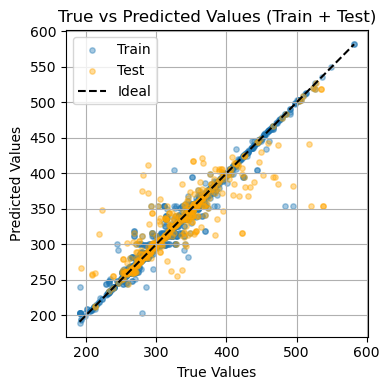

In [19]:
plt.figure(figsize=(4,4))

plt.scatter(y_train, y_train_pred, label='Train', alpha=0.4, s=15)
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.4, s=15, color='orange')

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Train + Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

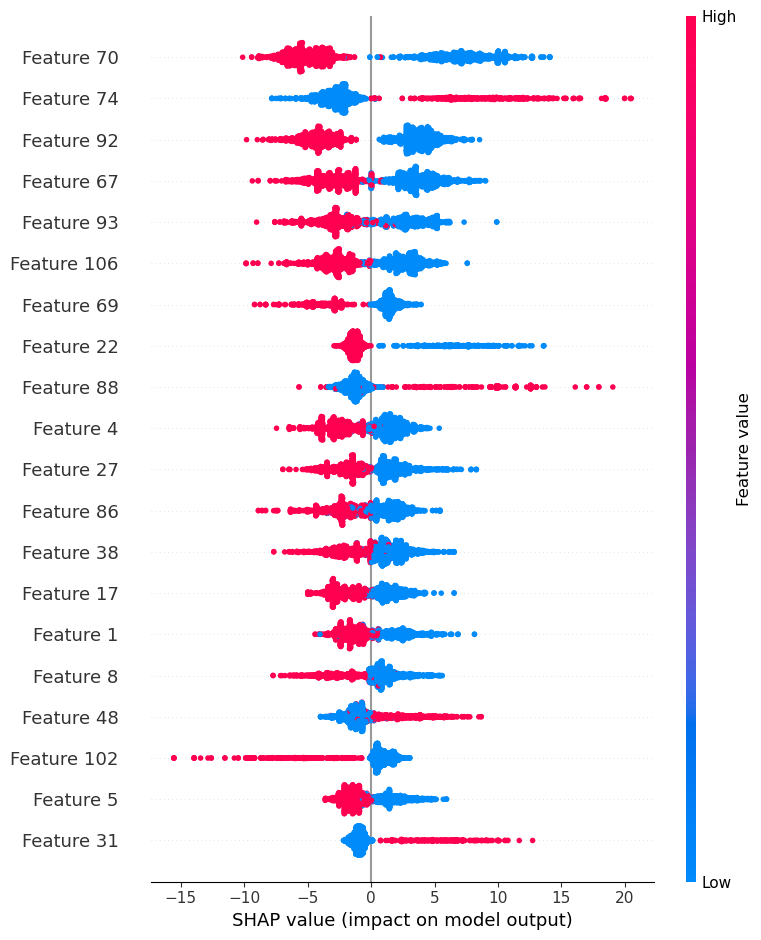

In [20]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train, max_display=20, color_bar=True,show=False)
plt.show()

In [21]:
# Convert SHAP values to a DataFrame
shap_values_df = pd.DataFrame(shap_values.values, columns=[f'Position_{i}' for i in range(X_train.shape[1])])

# Initialize a list to store mean SHAP values for positions where MF == 1
mean_shap_values = []

# Iterate over each position (feature) in the fingerprint
for i in range(X_train.shape[1]):
    # Filter SHAP values where the feature (fingerprint position) is set to 1
    shap_values_at_1 = shap_values_df[X_train[:, i] == 1][f'Position_{i}']

    # Calculate the mean SHAP value at this position when MF == 1
    mean_shap_value = shap_values_at_1.mean()
    mean_shap_values.append(mean_shap_value)

# Create a DataFrame to store the result
mean_shap_df = pd.DataFrame({
    'Position': range(len(mean_shap_values)),
    'Mean_SHAP_Value': mean_shap_values
})

print(mean_shap_df)

     Position  Mean_SHAP_Value
0           0         1.703382
1           1        -1.466398
2           2         0.338174
3           3         1.842993
4           4        -2.511351
..        ...              ...
103       103         2.733799
104       104        -0.532069
105       105        -2.932640
106       106        -2.890622
107       107       -12.523369

[108 rows x 2 columns]


In [22]:
mean_shap_df.to_csv('/home/ychen3338/project_2/code/melting/shap_feature_m.csv', index=False)

In [23]:
SHAP_PATH = '/home/ychen3338/project_2/code/melting/shap_feature_m.csv'
TRAIN_PATH = '/home/ychen3338/project_2/data/m_train.csv'

shap_df = pd.read_csv(SHAP_PATH)
shap_values = shap_df['Mean_SHAP_Value'].values
nonzero_bits = ((~np.isnan(shap_values)) & (shap_values != 0)).astype(int)
negative_bits = ((~np.isnan(shap_values)) & (shap_values < 0)).astype(int)
n_bits = len(nonzero_bits)

nonzero_fp = DataStructs.ExplicitBitVect(n_bits)
negative_fp = DataStructs.ExplicitBitVect(n_bits)
for i in range(n_bits):
    if nonzero_bits[i]:
        nonzero_fp.SetBit(i)
    if negative_bits[i]:
        negative_fp.SetBit(i)

train_df = pd.read_csv(TRAIN_PATH)
train_smiles = train_df['smiles'].tolist()
train_tms = train_df['Tm'].tolist()

In [25]:
dice_scores = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        dice = DataStructs.DiceSimilarity(fp, nonzero_fp)
        dice_scores.append(dice)

p25_dice = np.percentile(dice_scores, 25)
print(f"Step 1: 25th percentile of Dice similarity = {p25_dice:.3f}")

Step 1: 25th percentile of Dice similarity = 0.351


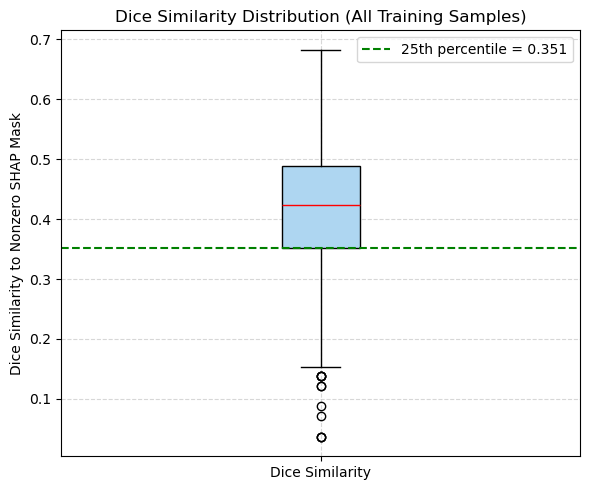

In [26]:
plt.figure(figsize=(6, 5))
plt.boxplot(dice_scores,
            labels=["Dice Similarity"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="red"))

plt.axhline(y=p25_dice, color='green', linestyle='--', label=f"25th percentile = {p25_dice:.3f}")

plt.ylabel("Dice Similarity to Nonzero SHAP Mask")
plt.title("Dice Similarity Distribution (All Training Samples)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
tanimoto_scores_tm_low = []
for smi, tm in zip(train_smiles, train_tms):
    if tm >= 298.15:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_tm_low.append(tanimoto)

tanimoto_scores_all = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_all.append(tanimoto)

pXX = np.percentile(tanimoto_scores_tm_low, 25)
print(f"Step 2: Tanimoto similarity of samples = {pXX:.3f}")


Step 2: Tanimoto similarity of samples = 0.258


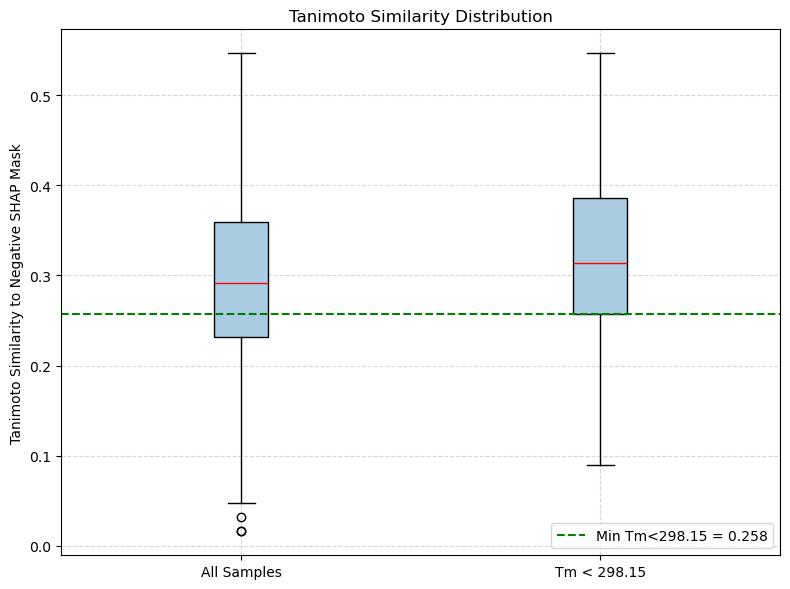

In [28]:
plt.figure(figsize=(8, 6))
plt.boxplot([tanimoto_scores_all, tanimoto_scores_tm_low],
            labels=["All Samples", "Tm < 298.15"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#A9CCE3"),
            medianprops=dict(color="red"))

plt.axhline(y=pXX, color='green', linestyle='--', label=f"Min Tm<298.15 = {pXX:.3f}")
plt.ylabel("Tanimoto Similarity to Negative SHAP Mask")
plt.title("Tanimoto Similarity Distribution")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
df = pd.read_csv('/home/ychen3338/project_2/code/melting/smiles_m.csv')

In [30]:
len(df)

31547007

In [31]:
df = df.drop_duplicates()

In [32]:
len(df)

12841289

In [33]:
df.to_csv('/home/ychen3338/project_2/code/melting/smiles_m.csv', index=False)

In [34]:
df = pd.read_csv('/home/ychen3338/project_2/data/after_m.csv')

In [35]:
len(df)

542918

In [37]:
df = df.drop_duplicates()
len(df)

542918